<a href="https://colab.research.google.com/github/EsserMishelle/Applied-Data-Science-ML/blob/main/Short_Term_Stock_Trend_Forecasting010121_020526_FBP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Objective
The objective of this project is to forecast the short-term closing price of NVIDIA (NVDA) stock using classical time-series models and compare their performance using information criteria and forecast accuracy.

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

import seaborn as sns
import os
import time

In [3]:
TICKERS = ['NVDA', 'SPY', 'AAPL']
START_DATE = '2021-01-01'
END_DATE = '2026-02-05'

stocks = yf.download(
    TICKERS,
    start=START_DATE,
    end=END_DATE,
    group_by='ticker',
    auto_adjust=True,
    prepost=True,
    threads=True,
    progress=False

)
stocks

Ticker             SPY                                                 \
Price             Open        High         Low       Close     Volume   
Date                                                                    
2021-01-04  350.343000  350.473700  340.550842  344.256744  110210800   
2021-01-05  343.612606  347.719896  343.565915  346.627716   66426200   
2021-01-06  345.115528  351.901919  344.564780  348.700073  107997700   
2021-01-07  351.080461  354.627660  350.903098  353.880890   68766800   
2021-01-08  355.271745  356.111868  352.013921  355.897186   71677200   
...                ...         ...         ...         ...        ...   
2026-01-29  696.390015  697.059998  684.830017  694.039978   97486200   
2026-01-30  691.789978  694.210022  687.119995  691.969971  101835100   
2026-02-02  689.580017  696.929993  689.419983  695.409973   79286500   
2026-02-03  696.210022  696.960022  684.030029  689.530029  107904600   
2026-02-04  690.349976  691.450012  681.760010  686.190002  105204600   

Ticker            NVDA                                                 \
Price             Open        High         Low       Close     Volume   
Date                                                                    
2021-01-04   13.067502   13.614215   12.926149   13.076726  560640000   
2021-01-05   13.063015   13.405801   13.050301   13.367160  322760000   
2021-01-06   13.185417   13.207854   12.550703   12.579123  580424000   
2021-01-07   12.931134   13.340235   12.850362   13.306579  461480000   
2021-01-08   13.325025   13.383361   13.005424   13.239515  292528000   
...                ...         ...         ...         ...        ...   
2026-01-29  191.339996  193.479996  186.059998  192.509995  171764400   
2026-01-30  191.210007  194.490005  189.470001  191.130005  179489500   
2026-02-02  187.199997  190.300003  184.880005  185.610001  165794100   
2026-02-03  186.240005  186.270004  176.229996  180.339996  204019600   
2026-02-04  179.460007  179.580002  171.910004  174.190002  207014100   

Ticker            AAPL                                                 
Price             Open        High         Low       Close     Volume  
Date                                                                   
2021-01-04  129.975346  130.062953  123.394807  125.974457  143301900  
2021-01-05  125.468268  128.242613  125.020474  127.531982   97664900  
2021-01-06  124.329344  127.570942  123.024914  123.239075  155088000  
2021-01-07  124.952346  128.135539  124.465620  127.444382  109578200  
2021-01-08  128.914274  129.108977  126.772682  128.544373  105158200  
...                ...         ...         ...         ...        ...  
2026-01-29  258.000000  259.649994  254.410004  258.279999   67253000  
2026-01-30  255.169998  261.899994  252.179993  259.480011   92443400  
2026-02-02  260.029999  270.489990  259.209991  270.010010   73913400  
2026-02-03  269.200012  271.880005  267.609985  269.480011   64394700  
2026-02-04  272.290009  278.950012  272.290009  276.489990   90545700  

[1278 rows x 15 columns]

In [4]:
stocks.columns

MultiIndex([( 'SPY',   'Open'),
            ( 'SPY',   'High'),
            ( 'SPY',    'Low'),
            ( 'SPY',  'Close'),
            ( 'SPY', 'Volume'),
            ('NVDA',   'Open'),
            ('NVDA',   'High'),
            ('NVDA',    'Low'),
            ('NVDA',  'Close'),
            ('NVDA', 'Volume'),
            ('AAPL',   'Open'),
            ('AAPL',   'High'),
            ('AAPL',    'Low'),
            ('AAPL',  'Close'),
            ('AAPL', 'Volume')],
           names=['Ticker', 'Price'])

In [5]:
stocks.info()


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1278 entries, 2021-01-04 to 2026-02-04
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (SPY, Open)     1278 non-null   float64
 1   (SPY, High)     1278 non-null   float64
 2   (SPY, Low)      1278 non-null   float64
 3   (SPY, Close)    1278 non-null   float64
 4   (SPY, Volume)   1278 non-null   int64  
 5   (NVDA, Open)    1278 non-null   float64
 6   (NVDA, High)    1278 non-null   float64
 7   (NVDA, Low)     1278 non-null   float64
 8   (NVDA, Close)   1278 non-null   float64
 9   (NVDA, Volume)  1278 non-null   int64  
 10  (AAPL, Open)    1278 non-null   float64
 11  (AAPL, High)    1278 non-null   float64
 12  (AAPL, Low)     1278 non-null   float64
 13  (AAPL, Close)   1278 non-null   float64
 14  (AAPL, Volume)  1278 non-null   int64  
dtypes: float64(12), int64(3)
memory usage: 159.8 KB


### The result shows the DataFrame has 2023 entries and 15 columns with no null values.

In [6]:
stocks.describe()

Ticker          SPY                                                       \
Price          Open         High          Low        Close        Volume   
count   1278.000000  1278.000000  1278.000000  1278.000000  1.278000e+03   
mean     473.766214   476.364855   470.925382   473.865181  7.616250e+07   
std       98.869751    98.894861    98.662051    98.820963  2.922574e+07   
min      334.148986   344.301416   333.096422   341.182007  2.604870e+07   
25%      393.922059   396.136927   392.266430   394.242142  5.689705e+07   
50%      433.573979   434.528799   430.446034   432.456085  7.151200e+07   
75%      554.246000   558.480187   550.618810   554.399582  8.974358e+07   
max      697.049988   697.840027   693.940002   695.489990  2.566114e+08   

Ticker         NVDA                                                       \
Price          Open         High          Low        Close        Volume   
count   1278.000000  1278.000000  1278.000000  1278.000000  1.278000e+03   
mean      69.356256    70.504904    68.054208    69.329726  3.907986e+08   
std       59.205625    59.987652    58.200129    59.103824  1.843901e+08   
min       10.957225    11.720265    10.799423    11.212903  6.552850e+07   
25%       19.451994    19.817180    19.049824    19.515130  2.365302e+08   
50%       42.366418    43.164094    41.713873    42.327452  3.756440e+08   
75%      121.724501   124.009573   118.226890   121.585546  5.028558e+08   
max      208.068415   212.178195   205.548551   207.028473  1.543911e+09   

Ticker         AAPL                                                       
Price          Open         High          Low        Close        Volume  
count   1278.000000  1278.000000  1278.000000  1278.000000  1.278000e+03  
mean     180.803343   182.764852   179.020228   180.980631  6.955189e+07  
std       41.095204    41.390629    40.838258    41.141424  2.983656e+07  
min      116.043170   117.378788   113.293925   113.440163  1.791060e+07  
25%      146.084915   147.988800   144.884859   146.439365  4.820820e+07  
50%      172.056247   174.155509   171.034104   172.122429  6.262950e+07  
75%      212.170790   214.495435   210.163797   212.640015  8.424670e+07  
max      286.200012   288.619995   283.299988   286.190002  3.186799e+08

In [7]:
type(stocks)

pandas.core.frame.DataFrame

In [8]:
# Divide the stocks DataFrame by TICKER and duplicate it.
nvda = stocks['NVDA'].copy()
spy = stocks['SPY'].copy()
aapl = stocks['AAPL'].copy()

# All indices are sorted chronologically to preserve temporal order.
nvda = nvda.sort_index()
spy = spy.sort_index()
aapl = aapl.sort_index()

## Define the prediction task

This project focuses on classical time-series forecasting methods demonstrated in class, comparing ARIMA, Prophet, and linear trend models using AIC and forecast error metrics.

In [9]:
# Predict whether NVDA’s 5-day return exceeds a minimum meaningful threshold.

# threshold = 0.01 #(1%)

# nvda['future_return_5d'] = nvda['Close'].pct_change(5).shift(-5)
# nvda['target'] = (nvda['future_return_5d'] > threshold).astype(int)
# nvda

# nvda['target'].value_counts(normalize=True)

In [10]:
nvda.head()
nvda.tail()

Price,Open,High,Low,Close,Volume
Date,,,,,
2026-01-29,191.339996,193.479996,186.059998,192.509995,171764400
2026-01-30,191.210007,194.490005,189.470001,191.130005,179489500
2026-02-02,187.199997,190.300003,184.880005,185.610001,165794100
2026-02-03,186.240005,186.270004,176.229996,180.339996,204019600
2026-02-04,179.460007,179.580002,171.910004,174.190002,207014100


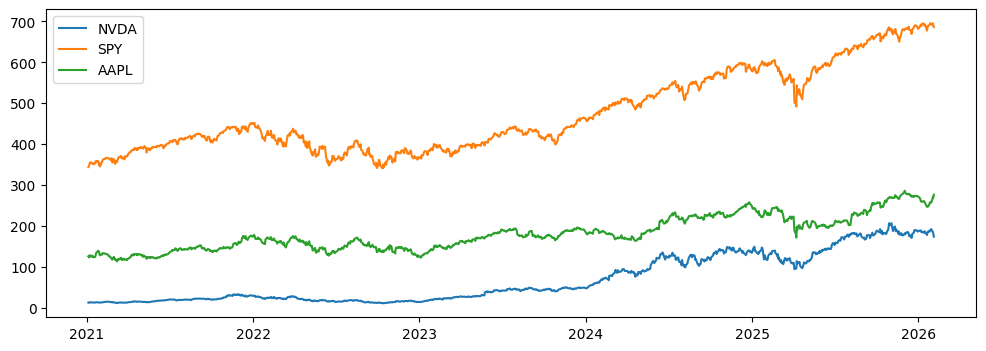

In [11]:
plt.figure(figsize=(12, 4))
plt.plot(nvda.index, nvda['Close'], label='NVDA')
plt.plot(spy.index, spy['Close'], label='SPY')
plt.plot(aapl.index, aapl['Close'], label='AAPL')
plt.legend()

plt.show()


The chart indicates that all three stocks (NVDA, SPY, AAPL) have a non-stationary series. NVDA's trend has minor incline but rose sharply starting from 2024. Even with minor drop in early 2025, the stock price seems to be going upward.

In [12]:
arima_ts = nvda['Close']
arima_ts.index = pd.to_datetime(arima_ts.index) # Make sure arima_ts has a datetime index
arima_ts = arima_ts.asfreq('B') # Only business work days (M-F)
arima_ts

,Close
Date,
2021-01-04,13.076726
2021-01-05,13.367160
2021-01-06,12.579123
2021-01-07,13.306579
2021-01-08,13.239515
...,...
2026-01-29,192.509995
2026-01-30,191.130005
2026-02-02,185.610001


## ARIMA (Autoregressive Integrated Moving Average)

### The ARIMA (Autoregressive Integrated Moving Average) model is a commonly used approach for forecasting time-series data. It works by combining information from past values of the series, changes between observations, and past forecast errors to model the underlying structure of the data. By incorporating **autoregression (AR), differencing (I), and moving-average terms (MA)**, ARIMA is able to capture trends and short-term patterns in historical data and use them to generate future forecasts.




## Choose Model (in-sample)
### ADF Differencing
#### Because ARIMA models require a stationary time series, the stationarity of the NVDA closing price data is first evaluated using the **Augmented Dickey–Fuller (ADF)** test. The ADF test checks for the presence of a unit root, where a failure to reject the null hypothesis indicates non-stationarity and the need for differencing before model fitting.

The test result shows the p-value (.97) is > .05 and the test statistic is above all critical values, so it fails to reject the null hypothesis. In other words, NVDA closing pric series is non-stationary.

To address this, first differencing is applied, which removes trend effects by modeling changes between consecutive observations rather than absolute price levels.

In [13]:
adfuller(arima_ts.diff().dropna())
print(adfuller(arima_ts.diff().dropna())[1])

1.3077884755699636e-07


After differencing, the ADF test strongly rejected the null hypothesis (p < 0.001) and that the transformed series now is stationary.
This proves that the first differencing is required to satisfy the assumptions of ARIMA modeling, corresponding to d = 1 in the ARIMA(p, d, q) specification.

### Autoregressive (AR) Models - obtain d

In [14]:
arima_ts_diff = arima_ts.diff().dropna()
arima_ts_diff

,Close
Date,
2021-01-05,0.290434
2021-01-06,-0.788037
2021-01-07,0.727456
2021-01-08,-0.067063
2021-01-11,0.343784
...,...
2026-01-29,0.989990
2026-01-30,-1.379990
2026-02-02,-5.520004


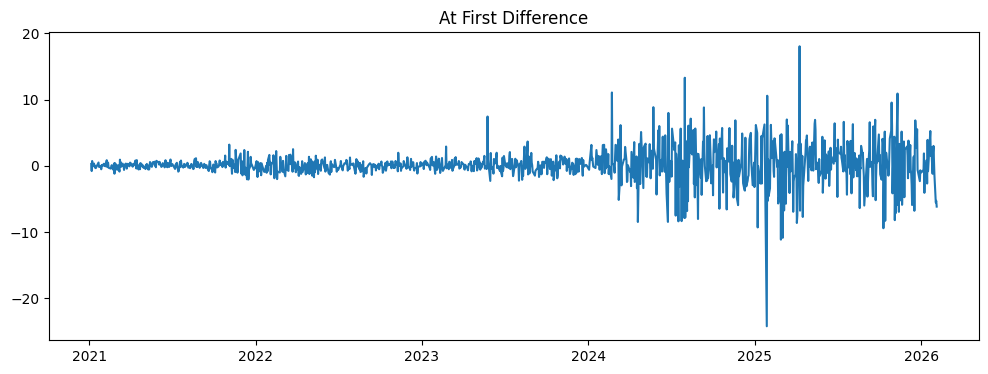

In [15]:
plt.figure(figsize=(12, 4))
plt.plot(arima_ts_diff)
plt.title('At First Difference')
plt.show()

## ACF/PACF - Candidate p, q

Text(0, 0.5, 'Correlation')

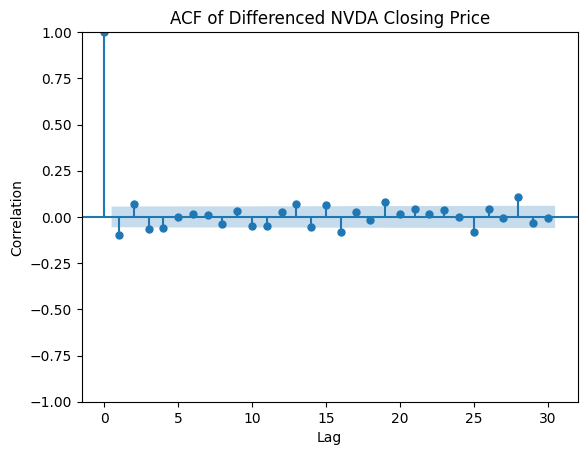

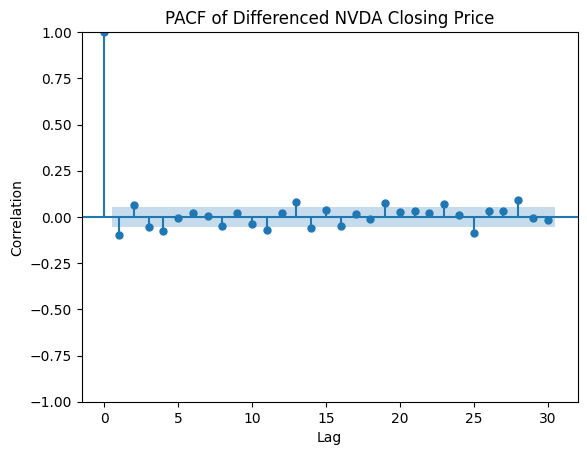

In [16]:
plot_acf(arima_ts_diff, lags=30)
plt.title('ACF of Differenced NVDA Closing Price')
plt.xlabel('Lag')
plt.ylabel('Correlation')

plot_pacf(arima_ts_diff, lags=30)
plt.title('PACF of Differenced NVDA Closing Price')
plt.xlabel('Lag')
plt.ylabel('Correlation')


###* ACF Plot Interpretation:
* Low Autocorrelation: Since all lag correlations are close to zero, this suggests that the series is likely to be white noise or has very short memory. There are no lags showing significant autocorrelation.
* Model Implications: If ACF does not show significant spikes, it indicates that you might consider a lower or possibly no moving average (MA) component.

### Interpretation of the ACF Plot:
Low Autocorrelation: Since all lag correlations are close to zero, this suggests that the series is likely to be white noise or has very short memory. There are no lags showing significant autocorrelation.
*Model Implications: If ACF does not show significant spikes, it indicates that you might consider a lower or possibly no moving average (MA) component.

After first differencing, both the ACF and PACF exhibit minimal autocorrelation, with no strong spikes beyond lag 1. This indicates that the differenced series behaves similarly to white noise, which is typical for financial return data. A parsimonious ARIMA(1,1,1) model is therefore selected to capture any remaining short-term dependence.

## AIC Grid Search - to obtain p, d, q

In [17]:
# from statsmodels.tsa.arima.model import ARIMA

best_aic = np.inf
best_order = None

# convert ts to only use business days
# ts = ts.asfreq('B')  # business days

# for the AR compnent (p)
for p in range(0, 5):
#for the MA component (q)
    for q in range(0, 5):
        arima_model = ARIMA(arima_ts, order=(p, 1, q))
        fit = arima_model.fit()
        print(f"ARIMA({p}, 1, {q}): AIC={fit.aic}")  #the best arima_model is the one we chose
#         if fit.aic < best_aic:
#             best_aic = fit.aic
#             best_order = (p, 1, q)
# best_aic, best_order

# # print(f"Best ARIMA model: ARIMA{best_order}, AIC={best_aic}")
# erro/warning just says order is not the best

ARIMA(0, 1, 0): AIC=6044.741104689406
ARIMA(0, 1, 1): AIC=6036.382111848954
ARIMA(0, 1, 2): AIC=6027.972683118487
ARIMA(0, 1, 3): AIC=6024.66993882941
ARIMA(0, 1, 4): AIC=6023.4409532986365
ARIMA(1, 1, 0): AIC=6034.612229247136
ARIMA(1, 1, 1): AIC=6029.29864228638
ARIMA(1, 1, 2): AIC=6027.514396325621
ARIMA(1, 1, 3): AIC=6023.055380237713
ARIMA(1, 1, 4): AIC=6025.055164609283
ARIMA(2, 1, 0): AIC=6027.164634980638
ARIMA(2, 1, 1): AIC=6028.368122548827
ARIMA(2, 1, 2): AIC=6023.199549046578
ARIMA(2, 1, 3): AIC=6025.055241124503
ARIMA(2, 1, 4): AIC=6023.164621886418
ARIMA(3, 1, 0): AIC=6027.173736219975
ARIMA(3, 1, 1): AIC=6024.3023159653085
ARIMA(3, 1, 2): AIC=6025.975393556389
ARIMA(3, 1, 3): AIC=6021.996622350686
ARIMA(3, 1, 4): AIC=6024.7788941028875
ARIMA(4, 1, 0): AIC=6023.985436560453
ARIMA(4, 1, 1): AIC=6025.733635339217
ARIMA(4, 1, 2): AIC=6022.790273585948


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


ARIMA(4, 1, 3): AIC=6022.736919850627
ARIMA(4, 1, 4): AIC=6023.411597986053


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


While ARIMA(4,1,4) achieved the lowest AIC, a simpler ARIMA(1,1,1) model was selected due to its interpretability and stability, given the weak autocorrelation structure of the differenced series.

Best model = ARIMA(4, 1, 4)

## Refit the Model Using Only the Training Data
### Train-Test-Split

In [18]:
arima_train = arima_ts.iloc[:-90]
arima_test = arima_ts.iloc[-90:]

### ARIMA Fit Train Data Only

In [19]:
arima_train_model = ARIMA(arima_train, order =(4,1,4), trend='t')
arima_train_fit= arima_train_model.fit()
arima_train_fit.summary()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  Close   No. Observations:                 1238
Model:                 ARIMA(4, 1, 4)   Log Likelihood               -2726.894
Date:                Fri, 06 Feb 2026   AIC                           5473.788
Time:                        19:09:56   BIC                           5524.992
Sample:                    01-04-2021   HQIC                          5493.047
                         - 10-01-2025                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1             0.1422      0.061      2.344      0.019       0.023       0.261
ar.L1         -0.0950      0.264     -0.360      0.719      -0.612       0.422
ar.L2         -0.1950      0.143     -1.363      0.173      -0.475       0.085
ar.L3          0.4232      0.188      2.248      0.025       0.054       0.792
ar.L4          0.4349      0.125      3.491      0.000       0.191       0.679
ma.L1         -0.0058      0.266     -0.022      0.983      -0.528       0.516
ma.L2          0.2902      0.133      2.179      0.029       0.029       0.551
ma.L3         -0.5098      0.198     -2.569      0.010      -0.899      -0.121
ma.L4         -0.4102      0.139     -2.953      0.003      -0.682      -0.138
sigma2         5.5933      0.091     61.438      0.000       5.415       5.772
===================================================================================
Ljung-Box (L1) (Q):                   0.22   Jarque-Bera (JB):             13491.39
Prob(Q):                              0.64   Prob(JB):                         0.00
Heteroskedasticity (H):              26.12   Skew:                            -0.76
Prob(H) (two-sided):                  0.00   Kurtosis:                        19.11
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

### Diagnostic Check (still in-sample)
## Chart fit.resid

In [20]:
resid = arima_train_fit.resid.dropna()
resid

,0
Date,
2021-01-04,12.934520
2021-01-05,0.148237
2021-01-06,-0.913257
2021-01-07,0.474995
2021-01-08,-0.067082
...,...
2025-09-25,1.247693
2025-09-26,0.064134
2025-09-29,3.279012


#### The residual dignostic chart checks training assumptions and validate the residual patterns are just white noise and that (4, 1,4) is not underfitting

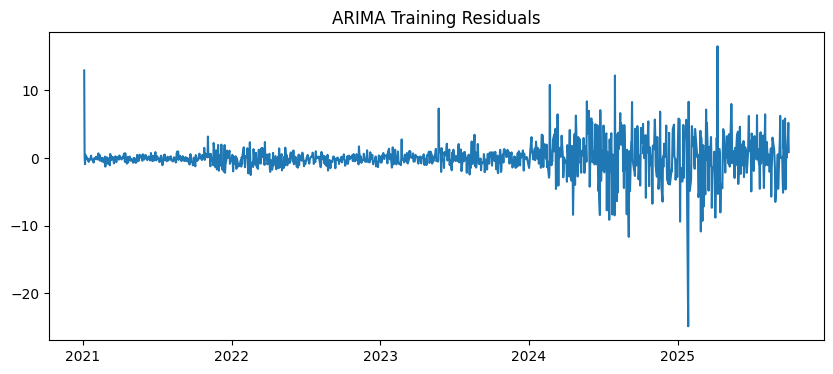

In [21]:
plt.figure(figsize=(10,4))
plt.plot(resid)
plt.title('ARIMA Training Residuals')
plt.show()

## Plot acf and pact of fit.resid

<Figure size 1000x400 with 0 Axes>

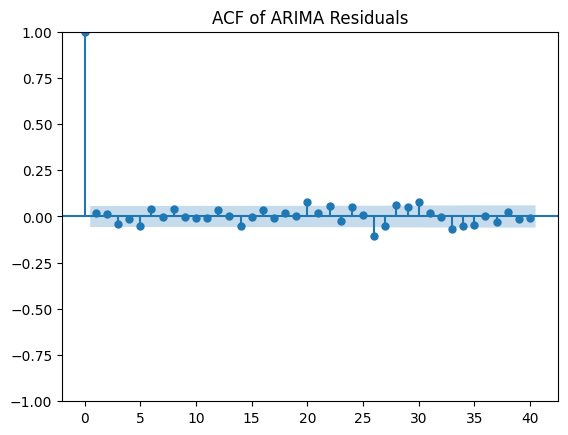

<Figure size 1000x400 with 0 Axes>

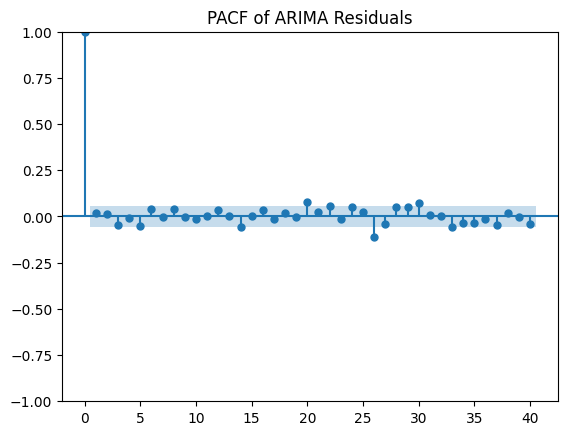

In [22]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plot_acf(resid, lags=40)
plt.title('ACF of ARIMA Residuals')
plt.show()

plt.figure(figsize=(10,4))
plot_pacf(resid, lags=40)
plt.title('PACF of ARIMA Residuals')
plt.show()



In [23]:
forecast = arima_train_fit.get_forecast(steps=len(arima_test))
pred = forecast.predicted_mean
pred


,predicted_mean
2025-10-02,187.871749
2025-10-03,187.599239
2025-10-06,187.333342
2025-10-07,187.679148
2025-10-08,187.923510
...,...
2026-01-29,198.660788
2026-01-30,198.802905
2026-02-02,198.945032
2026-02-03,199.087337


In [24]:
print(f'arima_test has: {arima_test.isnull().sum()} NaNs')
print(f'pred has: {pred.isnull().sum()} NaNs')

# arima_test set has NaN because of market holidays.
# pred has no NaNs because ARIMA predicts every step


arima_test_clean = arima_test.dropna()
pred_clean = pred.loc[arima_test_clean.index]


arima_test has: 4 NaNs
pred has: 0 NaNs


### Remove market holidays from ARIMA train dataset

In [25]:
arima_test_clean = arima_test.dropna()
pred_clean = pred.loc[arima_test_clean.index]

In [27]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

mae = mean_absolute_error(arima_test_clean, pred_clean)
rmse = np.sqrt(mean_squared_error(arima_test_clean, pred_clean))
mape = mean_absolute_error(arima_test_clean, pred_clean) / np.mean(np.abs(arima_test_clean))


mae, rmse

(9.419689684102282, np.float64(10.806607322856616))

In [28]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

def arima_metrics(train, test, fit):
    """
    train: training time series (pd.Series)
    test: test time series (pd.Series)
    fit: fitted ARIMA model on train
    """

    # -------- TRAIN predictions (in-sample) --------
    y_pred_train = fit.fittedvalues

    # align and drop NaNs
    train_eval = pd.concat([train, y_pred_train], axis=1).dropna()
    train_eval.columns = ['actual', 'pred']

    # -------- TEST predictions (out-of-sample) --------
    forecast = fit.get_forecast(steps=len(test))
    y_pred_test = forecast.predicted_mean

    test_eval = pd.concat([test, y_pred_test], axis=1).dropna()
    test_eval.columns = ['actual', 'pred']

    # -------- METRICS --------
    metrics = {
        'MAE_train': mean_absolute_error(train_eval['actual'], train_eval['pred']),
        'MAE_test': mean_absolute_error(test_eval['actual'], test_eval['pred']),

        'RMSE_train': np.sqrt(mean_squared_error(train_eval['actual'], train_eval['pred'])),
        'RMSE_test': np.sqrt(mean_squared_error(test_eval['actual'], test_eval['pred'])),

        'MAPE_train': mean_absolute_percentage_error(train_eval['actual'], train_eval['pred']),
        'MAPE_test': mean_absolute_percentage_error(test_eval['actual'], test_eval['pred']),
    }

    return metrics


In [29]:
arima_results = arima_metrics(
    arima_train,
    arima_test,
    arima_train_fit
)

arima_results

{'MAE_train': 1.4084407437249777,
 'MAE_test': 9.419689684102282,
 'RMSE_train': np.float64(2.416116696488679),
 'RMSE_test': np.float64(10.806607322856616),
 'MAPE_train': 0.025741006243879105,
 'MAPE_test': 0.05109314462316229}

## Get ARIMA forecast for the full dataset

In [31]:
arima_full_model = ARIMA(
    arima_ts,
    order=(4,1,4),   # use the order you selected
    trend='t'
)

arima_full_fit = arima_full_model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


### Forecast next 30 business days

In [32]:
arima_forecast_30 = arima_full_fit.get_forecast(steps=30)
pred_30 = arima_forecast_30.predicted_mean
ci_30 = arima_forecast_30.conf_int()


Plot 2021-2026 + Forecast

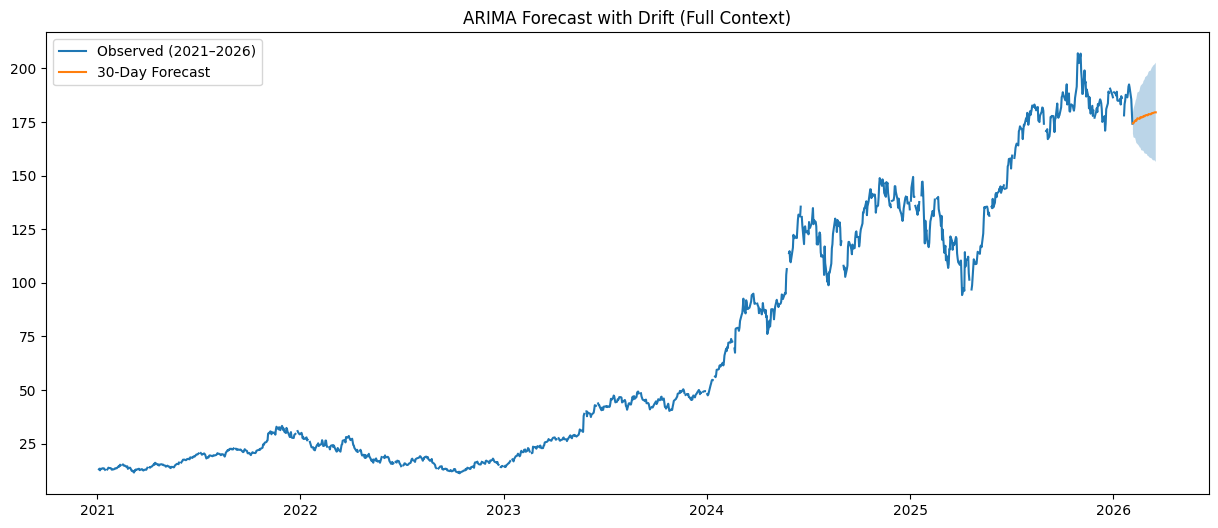

In [33]:
plt.figure(figsize=(15,6))

plt.plot(arima_ts, label='Observed (2021–2026)')
plt.plot(pred_30, label='30-Day Forecast')
plt.fill_between(
    ci_30.index,
    ci_30.iloc[:,0],
    ci_30.iloc[:,1],
    alpha=0.3
)

plt.legend()
plt.title('ARIMA Forecast with Drift (Full Context)')
plt.show()


Business days only and next trading day are applied to see the next 30 days forecase along with the last 90 days trend.

Plot ZOOMED view (last 90 days + 30 days prediction)

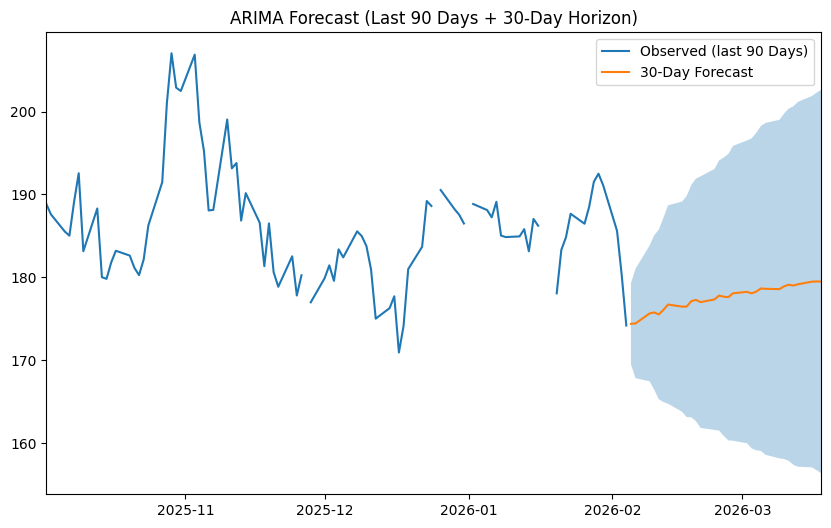

In [34]:
start_zoom = arima_ts.index[-90]
end_zoom = ci_30.index[-1]

plt.figure(figsize=(10,6))

plt.plot(
    arima_ts.loc[start_zoom:],
    label ='Observed (last 90 Days)'
)

plt.plot(
    pred_30, label='30-Day Forecast')

plt.fill_between(
    ci_30.index,
    ci_30.iloc[:,0],
    ci_30.iloc[:,1],
    alpha=.3
)

plt.xlim(start_zoom, end_zoom)

plt.legend()
plt.title('ARIMA Forecast (Last 90 Days + 30-Day Horizon)')
plt.show()

## An ARIMA(3,1,3) model with a drift term was also evaluated to account for persistent upward movement in the series. While the drift-adjusted model produces a modest upward forecast, it remains conservative and does not extrapolate recent price spikes. This behavior is consistent with financial theory, where short-term stock price movements are largely unpredictable and best modeled as a random walk with drift.

<Figure size 1200x600 with 0 Axes>

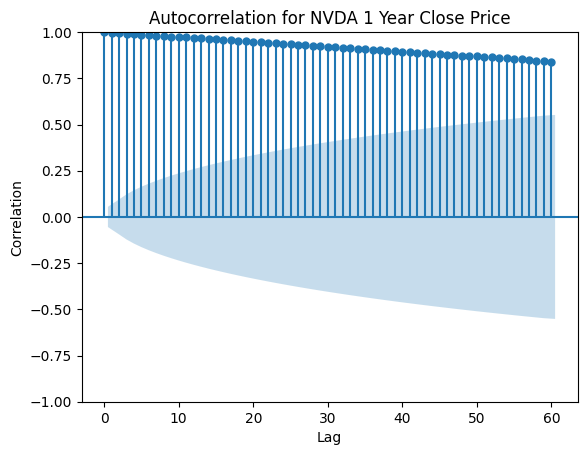

In [35]:
# one year
plt.figure(figsize=(12, 6))
plot_acf(nvda['Close'], lags=60, title='Autocorrelation for NVDA 1 Year Close Price')
plt.xlabel('Lag') # x axis - lag
plt.ylabel('Correlation') # y - corr
plt.show()

# OHLCV exists, but the modeled series is univariate.

This analysis focuses on the closing price series, treating the problem as a univariate time-series forecasting task.

Model 1 — ARIMA (primary classical model)

What you do:

Fit ARIMA on Close

Compare AIC across candidate orders

Generate a forecast

What you evaluate:

AIC (model selection)

RMSE on a hold-out period

Forecast plot

You do not need to over-tune. Simple is fine.

Model 2 — Prophet (trend-based baseline)

What you do:

Fit Prophet on ds (date) and y (Close)

Generate forecast

Plot trend + forecast

What you evaluate:

Forecast error (RMSE / MAE)

Visual comparison to ARIMA

No AIC here — Prophet doesn’t use it.

Model 3 — Linear Regression (naïve baseline)

What this really is:

A time-trend model, not ML

t = np.arange(len(y))
LinearRegression().fit(t.reshape(-1,1), y)

Purpose:

establishes a baseline

shows why time-series structure matters

mirrors Jeff’s synthetic example



---



# LR Model

In [38]:
LR_ts = nvda['Close']

In [39]:
df = pd.DataFrame({'y':LR_ts})

for lag in [1, 7, 14, 21, 30, 60]:
  df[f'lag_{lag}'] = df['y'].shift(lag)

df

,y,lag_1,lag_7,lag_14,lag_21,lag_30,lag_60
Date,,,,,,,
2021-01-04,13.076726,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-05,13.367160,13.076726,NaN,NaN,NaN,NaN,NaN
2021-01-06,12.579123,13.367160,NaN,NaN,NaN,NaN,NaN
2021-01-07,13.306579,12.579123,NaN,NaN,NaN,NaN,NaN
2021-01-08,13.239515,13.306579,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
2026-01-29,192.509995,191.520004,178.070007,185.039993,188.220001,176.289993,202.478729
2026-01-30,191.130005,192.509995,183.320007,184.860001,187.539993,177.720001,206.868484
2026-02-02,185.610001,191.130005,184.839996,184.940002,186.500000,170.940002,198.678940


<Axes: >

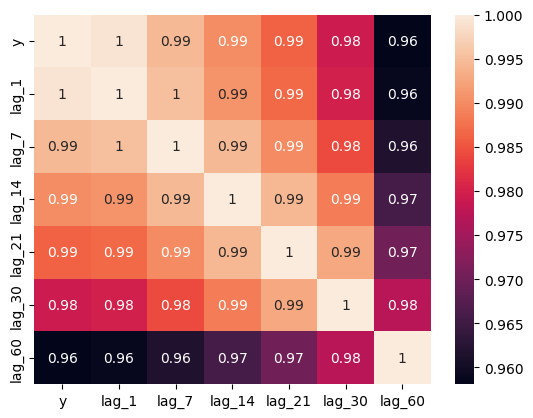

In [40]:
sns.heatmap(df.corr(), annot=True)

In [41]:
for num in [1, 7, 14, 30, 60]:
  df[f'rolling_mean_{num}'] = df['y'].rolling(num).mean()

df['rolling_std_7'] = df['y'].rolling(7).std() # volatility over 7 days. high std == market instability, demand spikes, regime changes
df['rolling_std_30'] = df['y'].rolling(30).std()
df['rolling_std_60'] = df['y'].rolling(60).std()

df.head(61)

# df.tail(30)

,y,lag_1,lag_7,lag_14,lag_21,lag_30,lag_60,rolling_mean_1,rolling_mean_7,rolling_mean_14,rolling_mean_30,rolling_mean_60,rolling_std_7,rolling_std_30,rolling_std_60
Date,,,,,,,,,,,,,,,
2021-01-04,13.076726,NaN,NaN,NaN,NaN,NaN,NaN,13.076726,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-05,13.367160,13.076726,NaN,NaN,NaN,NaN,NaN,13.367160,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-06,12.579123,13.367160,NaN,NaN,NaN,NaN,NaN,12.579123,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-07,13.306579,12.579123,NaN,NaN,NaN,NaN,NaN,13.306579,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-08,13.239515,13.306579,NaN,NaN,NaN,NaN,NaN,13.239515,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-03-25,12.504412,12.611897,13.258551,12.426555,14.458342,14.722847,NaN,12.504412,12.874642,12.772394,13.442975,NaN,0.298999,0.995709,NaN
2021-03-26,12.807664,12.504412,13.308430,11.560740,13.270182,15.207982,NaN,12.807664,12.803104,12.861460,13.362964,NaN,0.229816,0.944092,NaN
2021-03-29,12.916393,12.807664,12.691202,12.489450,13.676042,14.919294,NaN,12.916393,12.835274,12.891956,13.296201,NaN,0.227289,0.900029,NaN


<Axes: >

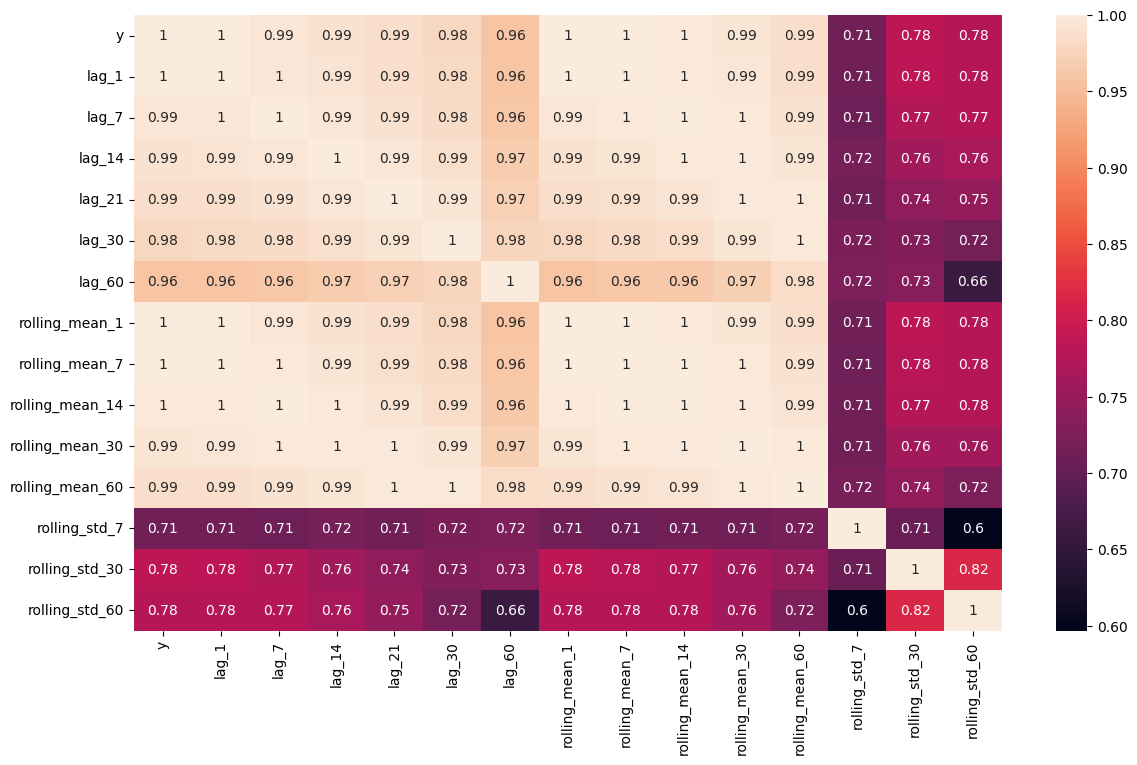

In [42]:
plt.figure(figsize=(14, 8))
plt.plot(df['y'], label='NVDA')
sns.heatmap(df.corr(), annot=True)

lag features have stron correlation with one another (>.97).

rolling_sd_60 has the weakest correlation with rolling_sd_7 (.71). Other rolling features have moderate correlation with other rolling features (high 70's and mid 80's)

In [43]:
df['day_of_week'] = df.index.dayofweek
df['month_of_year'] = df.index.month
df['month'] = df.index.month
df['year'] = df.index.year
df['quarter'] = df.index.quarter
df

,y,lag_1,lag_7,lag_14,lag_21,lag_30,lag_60,rolling_mean_1,rolling_mean_7,rolling_mean_14,rolling_mean_30,rolling_mean_60,rolling_std_7,rolling_std_30,rolling_std_60,day_of_week,month_of_year,month,year,quarter
Date,,,,,,,,,,,,,,,,,,,,
2021-01-04,13.076726,NaN,NaN,NaN,NaN,NaN,NaN,13.076726,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1,1,2021,1
2021-01-05,13.367160,13.076726,NaN,NaN,NaN,NaN,NaN,13.367160,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1,1,2021,1
2021-01-06,12.579123,13.367160,NaN,NaN,NaN,NaN,NaN,12.579123,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,1,1,2021,1
2021-01-07,13.306579,12.579123,NaN,NaN,NaN,NaN,NaN,13.306579,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,1,1,2021,1
2021-01-08,13.239515,13.306579,NaN,NaN,NaN,NaN,NaN,13.239515,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,1,1,2021,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-01-29,192.509995,191.520004,178.070007,185.039993,188.220001,176.289993,202.478729,192.509995,187.835715,186.067858,185.380001,185.435852,3.345388,4.878803,6.288222,3,1,1,2026,1
2026-01-30,191.130005,192.509995,183.320007,184.860001,187.539993,177.720001,206.868484,191.130005,188.951429,186.515715,185.827001,185.173544,2.854725,4.765796,5.677639,4,1,1,2026,1
2026-02-02,185.610001,191.130005,184.839996,184.940002,186.500000,170.940002,198.678940,185.610001,189.061430,186.563572,186.316001,184.955728,2.679343,3.850312,5.394360,0,2,2,2026,1


In [44]:
df['day_name']= df.index.day_name()
df.groupby('day_name')
df

,y,lag_1,lag_7,lag_14,lag_21,lag_30,lag_60,rolling_mean_1,rolling_mean_7,rolling_mean_14,...,rolling_mean_60,rolling_std_7,rolling_std_30,rolling_std_60,day_of_week,month_of_year,month,year,quarter,day_name
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-04,13.076726,NaN,NaN,NaN,NaN,NaN,NaN,13.076726,NaN,NaN,...,NaN,NaN,NaN,NaN,0,1,1,2021,1,Monday
2021-01-05,13.367160,13.076726,NaN,NaN,NaN,NaN,NaN,13.367160,NaN,NaN,...,NaN,NaN,NaN,NaN,1,1,1,2021,1,Tuesday
2021-01-06,12.579123,13.367160,NaN,NaN,NaN,NaN,NaN,12.579123,NaN,NaN,...,NaN,NaN,NaN,NaN,2,1,1,2021,1,Wednesday
2021-01-07,13.306579,12.579123,NaN,NaN,NaN,NaN,NaN,13.306579,NaN,NaN,...,NaN,NaN,NaN,NaN,3,1,1,2021,1,Thursday
2021-01-08,13.239515,13.306579,NaN,NaN,NaN,NaN,NaN,13.239515,NaN,NaN,...,NaN,NaN,NaN,NaN,4,1,1,2021,1,Friday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-01-29,192.509995,191.520004,178.070007,185.039993,188.220001,176.289993,202.478729,192.509995,187.835715,186.067858,...,185.435852,3.345388,4.878803,6.288222,3,1,1,2026,1,Thursday
2026-01-30,191.130005,192.509995,183.320007,184.860001,187.539993,177.720001,206.868484,191.130005,188.951429,186.515715,...,185.173544,2.854725,4.765796,5.677639,4,1,1,2026,1,Friday
2026-02-02,185.610001,191.130005,184.839996,184.940002,186.500000,170.940002,198.678940,185.610001,189.061430,186.563572,...,184.955728,2.679343,3.850312,5.394360,0,2,2,2026,1,Monday


In [45]:
df.index.dayofyear

Index([ 4,  5,  6,  7,  8, 11, 12, 13, 14, 15,
       ...
       22, 23, 26, 27, 28, 29, 30, 33, 34, 35],
      dtype='int32', name='Date', length=1278)

In [46]:
df['day_of_year'] = df.index.dayofyear
df # Day of year

,y,lag_1,lag_7,lag_14,lag_21,lag_30,lag_60,rolling_mean_1,rolling_mean_7,rolling_mean_14,...,rolling_std_7,rolling_std_30,rolling_std_60,day_of_week,month_of_year,month,year,quarter,day_name,day_of_year
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-04,13.076726,NaN,NaN,NaN,NaN,NaN,NaN,13.076726,NaN,NaN,...,NaN,NaN,NaN,0,1,1,2021,1,Monday,4
2021-01-05,13.367160,13.076726,NaN,NaN,NaN,NaN,NaN,13.367160,NaN,NaN,...,NaN,NaN,NaN,1,1,1,2021,1,Tuesday,5
2021-01-06,12.579123,13.367160,NaN,NaN,NaN,NaN,NaN,12.579123,NaN,NaN,...,NaN,NaN,NaN,2,1,1,2021,1,Wednesday,6
2021-01-07,13.306579,12.579123,NaN,NaN,NaN,NaN,NaN,13.306579,NaN,NaN,...,NaN,NaN,NaN,3,1,1,2021,1,Thursday,7
2021-01-08,13.239515,13.306579,NaN,NaN,NaN,NaN,NaN,13.239515,NaN,NaN,...,NaN,NaN,NaN,4,1,1,2021,1,Friday,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-01-29,192.509995,191.520004,178.070007,185.039993,188.220001,176.289993,202.478729,192.509995,187.835715,186.067858,...,3.345388,4.878803,6.288222,3,1,1,2026,1,Thursday,29
2026-01-30,191.130005,192.509995,183.320007,184.860001,187.539993,177.720001,206.868484,191.130005,188.951429,186.515715,...,2.854725,4.765796,5.677639,4,1,1,2026,1,Friday,30
2026-02-02,185.610001,191.130005,184.839996,184.940002,186.500000,170.940002,198.678940,185.610001,189.061430,186.563572,...,2.679343,3.850312,5.394360,0,2,2,2026,1,Monday,33


In [47]:
df


,y,lag_1,lag_7,lag_14,lag_21,lag_30,lag_60,rolling_mean_1,rolling_mean_7,rolling_mean_14,...,rolling_std_7,rolling_std_30,rolling_std_60,day_of_week,month_of_year,month,year,quarter,day_name,day_of_year
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-04,13.076726,NaN,NaN,NaN,NaN,NaN,NaN,13.076726,NaN,NaN,...,NaN,NaN,NaN,0,1,1,2021,1,Monday,4
2021-01-05,13.367160,13.076726,NaN,NaN,NaN,NaN,NaN,13.367160,NaN,NaN,...,NaN,NaN,NaN,1,1,1,2021,1,Tuesday,5
2021-01-06,12.579123,13.367160,NaN,NaN,NaN,NaN,NaN,12.579123,NaN,NaN,...,NaN,NaN,NaN,2,1,1,2021,1,Wednesday,6
2021-01-07,13.306579,12.579123,NaN,NaN,NaN,NaN,NaN,13.306579,NaN,NaN,...,NaN,NaN,NaN,3,1,1,2021,1,Thursday,7
2021-01-08,13.239515,13.306579,NaN,NaN,NaN,NaN,NaN,13.239515,NaN,NaN,...,NaN,NaN,NaN,4,1,1,2021,1,Friday,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-01-29,192.509995,191.520004,178.070007,185.039993,188.220001,176.289993,202.478729,192.509995,187.835715,186.067858,...,3.345388,4.878803,6.288222,3,1,1,2026,1,Thursday,29
2026-01-30,191.130005,192.509995,183.320007,184.860001,187.539993,177.720001,206.868484,191.130005,188.951429,186.515715,...,2.854725,4.765796,5.677639,4,1,1,2026,1,Friday,30
2026-02-02,185.610001,191.130005,184.839996,184.940002,186.500000,170.940002,198.678940,185.610001,189.061430,186.563572,...,2.679343,3.850312,5.394360,0,2,2,2026,1,Monday,33


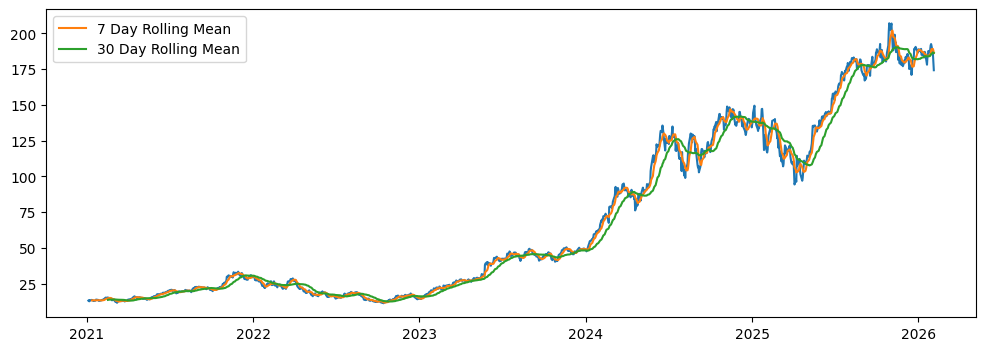

In [48]:
plt.figure(figsize=(12, 4))
plt.plot(df['y'])
plt.plot(df['rolling_mean_7'], label='7 Day Rolling Mean')
plt.plot(df['rolling_mean_30'], label='30 Day Rolling Mean')
plt.legend()

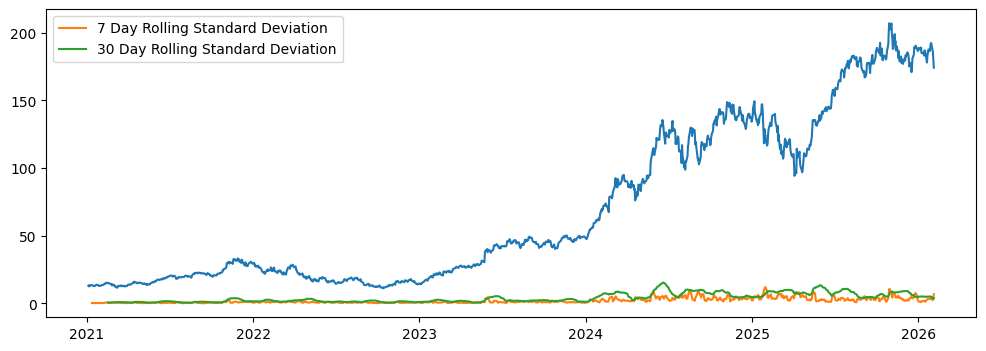

In [49]:
plt.figure(figsize=(12, 4))
plt.plot(df['y'])
plt.plot(df['rolling_std_7'], label='7 Day Rolling Standard Deviation')
plt.plot(df['rolling_std_30'], label='30 Day Rolling Standard Deviation')
plt.legend(); # std are very consistent over time

<Axes: xlabel='year'>

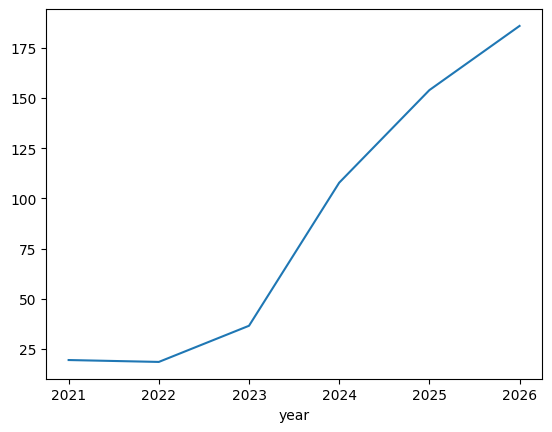

In [50]:
df.groupby('year')['y'].mean().plot(kind='line')  # Avg closing vale by year

<Axes: xlabel='quarter'>

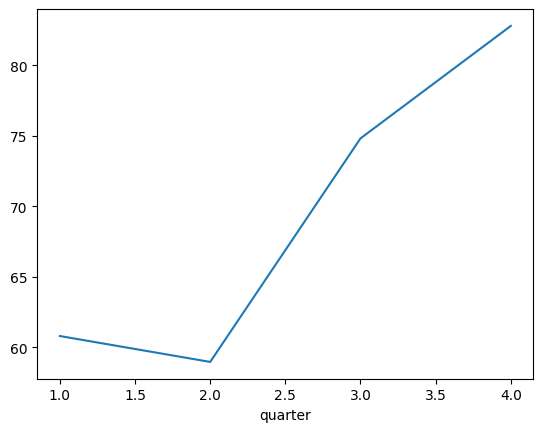

In [51]:
df.groupby('quarter')['y'].mean().plot(kind='line')

<Axes: xlabel='month'>

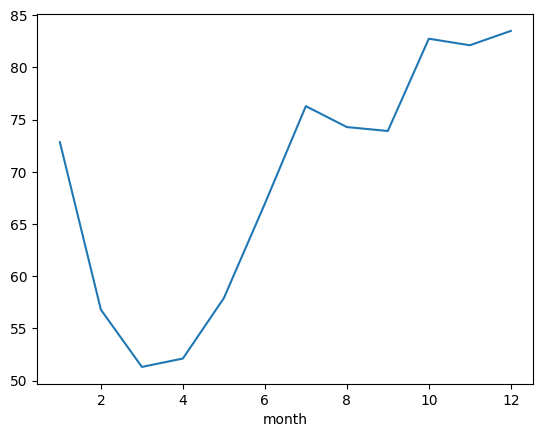

In [52]:
df.groupby('month')['y'].mean().plot(kind='line')

<Axes: xlabel='week_of_year'>

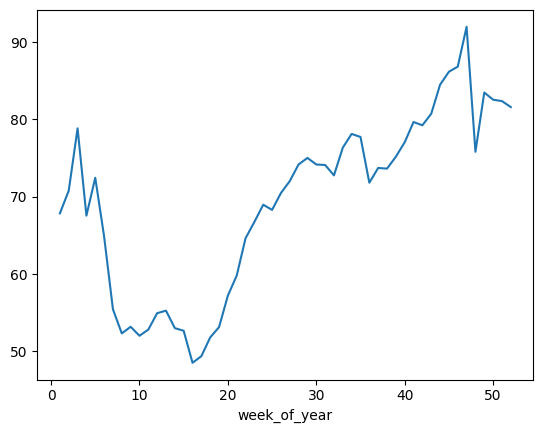

In [53]:
df['week_of_year'] = df.index.isocalendar().week
df.groupby('week_of_year')['y'].mean().plot(kind='line') # same trend.
# they do look the same but granuality matters

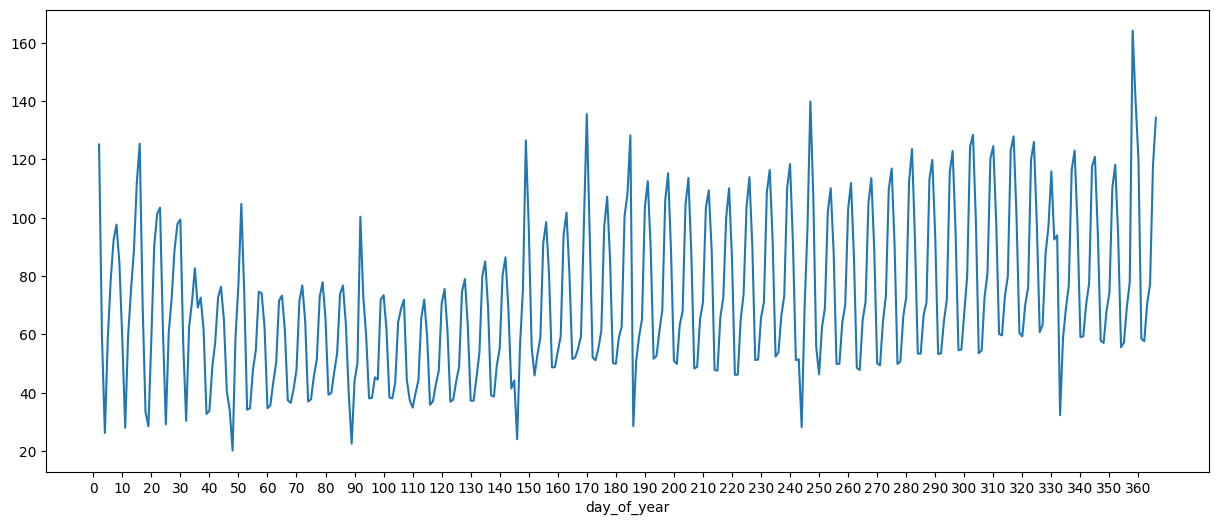

In [54]:
plt.figure(figsize=(15,6))
# df['day_of_year'] = df.index.dayofyear
df.groupby('day_of_year')['y'].mean().plot(kind='line')
# df.groupby('day_of_year')['y'].mean().sort_index(ascending=False).plot(kind='line')
plt.xticks(range(0, 365, 10));

<Axes: xlabel='day_of_year'>

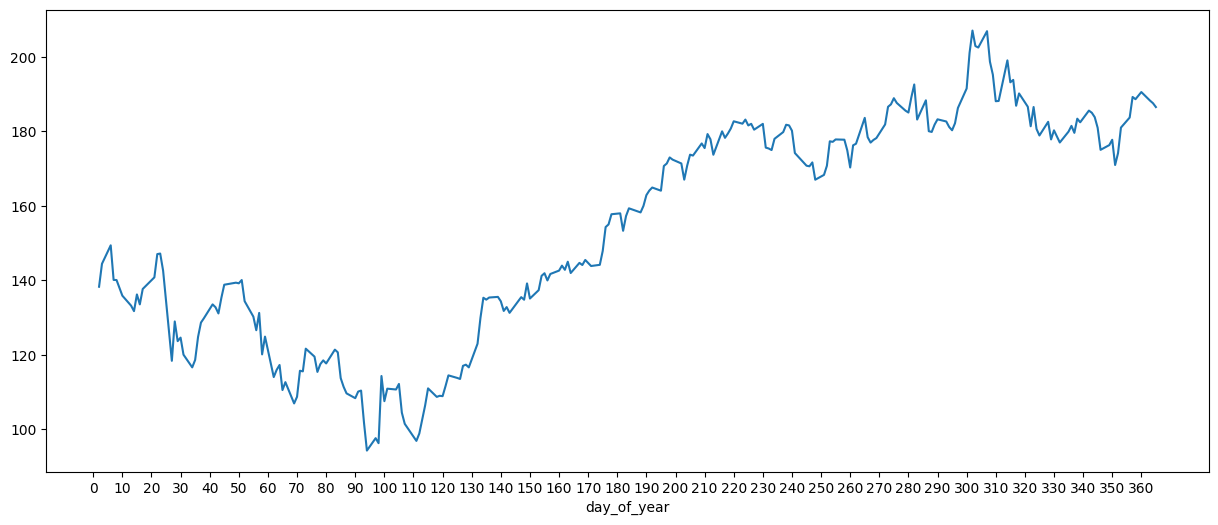

In [55]:
# checking special events around day 180-185

plt.figure(figsize=(15,6))

# df_2018 = df[df.index.year == 2018]
# df_2019 = df[df.index.year == 2019]
# df_2020 = df[df.index.year == 2020]
# df_2021 = df[df.index.year == 2021]
# df_2022 = df[df.index.year == 2022]
# df_2023 = df[df.index.year == 2023]
# df_2024 = df[df.index.year == 2024]
df_2025 = df[df.index.year == 2025]
plt.xticks(range(0, 365, 10));
df_2025.groupby('day_of_year')['y'].mean().plot(kind='line')

PoeL The spike in the 'day of year' data may be an outlier or a result of a specific event, but it might not be reflected in the overall trend. The event happens at the end of June and the beginning of July.


Poe:Week 27:

The data is indexed within Week 27, which may correlate with specific quarterly earnings or business cycles, particularly for tech companies.
Potential Hints
Earnings Reports: This period is often close to the end of Q2 for many companies, suggesting they might have released preliminary earnings or forecasts.
Market Sentiment: Stock performance might reflect positive market sentiment, possibly due to news about product launches, partnerships, or broader market trends affecting tech stocks.
Analyst Upgrades: Increased prices may also indicate market reactions to analyst upgrades or target price increases.



## Stocks in general seem to rally toward the end of the year. That might explain the upward trend toward Dec and ending in the month of Jan

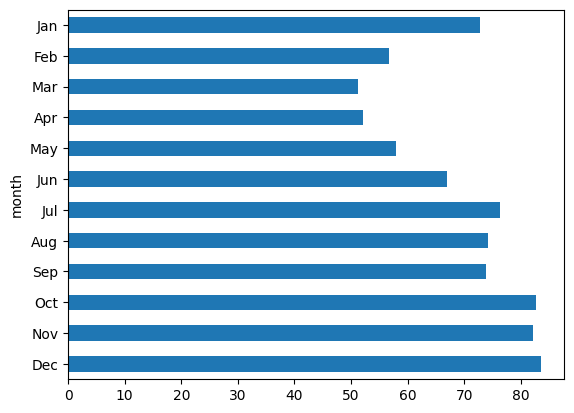

In [56]:
df['month'] = df.index.month
df.groupby('month')['y'].mean().sort_index(ascending=False).plot(kind='barh')
plt.yticks(range(12), ['Dec', 'Nov', 'Oct', 'Sep', 'Aug', 'Jul', 'Jun', 'May',
                       'Apr', 'Mar', 'Feb', 'Jan']);



There's a huge spike around 185 day of the year. Must be some significant event.

In [57]:
# check on rows we have to drop

df.isnull().sum()/df.shape[0]

,0
y,0.000000
lag_1,0.000782
lag_7,0.005477
lag_14,0.010955
lag_21,0.016432
lag_30,0.023474
lag_60,0.046948
rolling_mean_1,0.000000
rolling_mean_7,0.004695
rolling_mean_14,0.010172


In [58]:
df.shape

(1278, 23)

Drop NaN in stock dataframe (30 days due to lag_30 field we created)

In [59]:
df_raw = df.copy() # Immutable reference. Set df_raw() as ground truth
df = df_raw.copy() # Make a working copy

In [60]:
# drop all NaN

df = df.dropna()

In [61]:
df.shape

(1218, 23)

In [62]:
df

,y,lag_1,lag_7,lag_14,lag_21,lag_30,lag_60,rolling_mean_1,rolling_mean_7,rolling_mean_14,...,rolling_std_30,rolling_std_60,day_of_week,month_of_year,month,year,quarter,day_name,day_of_year,week_of_year
Date,,,,,,,,,,,,,,,,,,,,,
2021-03-31,13.315411,12.840084,13.153811,12.961535,13.368653,14.864198,13.076726,13.315411,12.862065,12.945983,...,0.759872,0.775765,2,3,3,2021,1,Wednesday,90,13
2021-04-01,13.777774,13.315411,13.038595,12.824373,12.768842,14.787416,13.367160,13.777774,12.967662,13.014083,...,0.705886,0.777192,3,4,4,2021,2,Thursday,91,13
2021-04-05,13.953089,13.777774,12.611897,13.158796,12.335560,14.884640,12.579123,13.953089,13.159261,13.070819,...,0.643765,0.772323,0,4,4,2021,2,Monday,95,14
2021-04-06,13.827401,13.953089,12.504412,13.258551,12.426555,14.315491,13.306579,13.827401,13.348259,13.111451,...,0.617577,0.773729,1,4,4,2021,2,Tuesday,96,14
2021-04-07,14.108705,13.827401,12.807664,13.308430,11.560740,14.102342,13.239515,14.108705,13.534122,13.168613,...,0.617941,0.777881,2,4,4,2021,2,Wednesday,97,14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-01-29,192.509995,191.520004,178.070007,185.039993,188.220001,176.289993,202.478729,192.509995,187.835715,186.067858,...,4.878803,6.288222,3,1,1,2026,1,Thursday,29,5
2026-01-30,191.130005,192.509995,183.320007,184.860001,187.539993,177.720001,206.868484,191.130005,188.951429,186.515715,...,4.765796,5.677639,4,1,1,2026,1,Friday,30,5
2026-02-02,185.610001,191.130005,184.839996,184.940002,186.500000,170.940002,198.678940,185.610001,189.061430,186.563572,...,3.850312,5.394360,0,2,2,2026,1,Monday,33,6


In [63]:
# drop day_name column because it is string type
df.drop(columns = ['day_name'], inplace=True)

In [64]:
adfuller(df['y'])

(np.float64(0.09285058744795466),
 np.float64(0.9655695670203139),
 4,
 1213,
 {'1%': np.float64(-3.435752466943879),
  '5%': np.float64(-2.8639256700182405),
  '10%': np.float64(-2.5680401696175466)},
 np.float64(5705.08593950487))

In [65]:
df.shape

(1218, 22)

------------------
# Facebook Prophet

In [ ]:
from prophet import Prophet
import pandas as pd
import matplotlib.pyplot as plt

### Transform the dataset to Facebook Prophet required format.

In [ ]:
# Create Prophet dataset
prophet_nvda = nvda['Close'].reset_index()
prophet_nvda.columns = ['ds', 'y']
prophet_train = prophet_nvda.iloc[:-90]
prophet_test  = prophet_nvda.iloc[-90:]

prophet_nvda.head(10)

### Initialize the Prophet model
Prophet already includes: trend and atomatic changepoints

* Stock prices don't have meaningful daily/weekly seasonality.
* Yearly effects sometimes show up in tax cycles and earning cadence

In [ ]:
# Traing
prophet_model = Prophet(yearly_seasonality=True,
                        weekly_seasonality=False,
                        daily_seasonality=False)

prophet_model.fit(prophet_train)

# prophet_model.fit(prophet_nvda)

In [ ]:
# Create future dates
prophet_future = prophet_model.make_future_dataframe(periods=120, freq='B') #'B' for business days. 120 days == 90 test days + 30 future days

# Predict and generate forecast
prophet_forecast = prophet_model.predict(prophet_future) # Generate

  # forecast contains:
  # trend
  # yearly seasonality
  # forecast (yhat)
  # confidence intervals (yhat_lower, yhat_upper)

# prophet_prophet_forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

display(prophet_forecast.tail())
print()
display(prophet_forecast.head())

In [ ]:
prophet_eval = prophet_nvda.merge(
    prophet_forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']],
    on='ds',
    how='left',
)

In [ ]:
prophet_train_eval = prophet_eval.iloc[:-90]
prophet_test_eval  = prophet_eval.iloc[-90:]

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def mape(actual, pred):
    return np.mean(np.abs((actual - pred) / actual)) * 100

mae_train = mean_absolute_error(prophet_train_eval['y'], prophet_train_eval['yhat'])
mae_test = mean_absolute_error(prophet_test_eval['y'], prophet_test_eval['yhat'])

rmse_train = np.sqrt(mean_squared_error(prophet_train_eval['y'], prophet_train_eval['yhat']))
rmse_test = np.sqrt(mean_squared_error(prophet_test_eval['y'], prophet_test_eval['yhat']))

mape_train = mape(prophet_train_eval['y'], prophet_train_eval['yhat'])
mape_test = mape(prophet_test_eval['y'], prophet_test_eval['yhat'])

mae = mean_absolute_error(prophet_eval['y'], prophet_eval['yhat'])
rmse = np.sqrt(mean_squared_error(prophet_eval['y'], prophet_eval['yhat']))


print("===== PROPHET PERFORMANCE =====")
print(f"TRAIN  → MAE:  {mae_train:.2f}")
print(f"TRAIN  → RMSE: {rmse_train:.2f}")
print(f"TRAIN  → MAPE: {mape_train:.2f}%\n")

print(f"TEST   → MAE:  {mae_test:.2f}")
print(f"TEST   → RMSE: {rmse_test:.2f}")
print(f"TEST   → MAPE: {mape_test:.2f}%")

In [ ]:
# print('model:', type(arima_model))
# print('model:', type(prophet_model))
# print('prophet_model:', type(prophet_model))
# print('forecast:', type(forecast))


# model: <class 'statsmodels.tsa.arima.model.ARIMA'>
# model: <class 'prophet.forecaster.Prophet'>
# prophet_model: <class 'prophet.forecaster.Prophet'>
# forecast: <class 'pandas.core.frame.DataFrame'>


In [ ]:
# Plot the forecast
prophet_model.plot(prophet_forecast)
plt.title('Prophet Forecast for NVDA (30 Business Days)')
plt.show()


In [ ]:
plt.figure(figsize=(10,6))

# Actual data
plt.plot(prophet_train['ds'], prophet_train['y'],
         label='Train', linewidth=3, color='blue')

plt.plot(prophet_test['ds'], prophet_test['y'],
         label='Test', linewidth=3, color='green')

# Forecast
plt.plot(prophet_forecast['ds'], prophet_forecast['yhat'],
         label='Prophet Forecast', color='red', linewidth=2, alpha=0.7)

# Only shade future uncertainty
split_date = prophet_train['ds'].max()

forecast_future = prophet_forecast[
    prophet_forecast['ds'] > split_date
]

plt.fill_between(
    forecast_future['ds'],
    forecast_future['yhat_lower'],
    forecast_future['yhat_upper'],
    color='gray',
    alpha=0.3,
    label='95% CI'
)

# Train/Test split line
plt.axvline(
    x=split_date,
    color='black',
    linestyle='--',
    linewidth=1,
    label='Train/Test Split'
)

plt.title('NVDA Prophet Forecast — Train, Test, and Next 30 Business Days')



plt.axvspan(
    prophet_train['ds'].min(),
    prophet_train['ds'].max(),
    color='blue',
    alpha=0.10,
    label='Training Window'
)

plt.axvspan(
    prophet_train['ds'].max(),
    prophet_test['ds'].max(),
    color='green',
    alpha=0.10,
    label='Test Window'
)

plt.axvline(
    x=prophet_test['ds'].max(),
    color='darkgreen',
    linestyle=':',
    linewidth=1,
    label='End of Test'
)

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
plt.figure(figsize=(10,5))

# ----- Define boundaries -----
split_date = prophet_train['ds'].max()
zoom_start = split_date - pd.Timedelta(days=90)   # last 90 calendar days
test_end = prophet_test['ds'].max()               # end of test window

# Subset data for zoom
hist_zoom = prophet_nvda[prophet_nvda['ds'] >= zoom_start]
forecast_zoom = prophet_forecast[prophet_forecast['ds'] >= zoom_start]

# ----- Plot actual history (last 90 days) -----
plt.scatter(
    hist_zoom['ds'],
    hist_zoom['y'],
    color='orange',
    s=40,
    alpha=0.9,
    label='Observed (last 90 days)'
)

# ----- Plot forecast -----
plt.plot(
    forecast_zoom['ds'],
    forecast_zoom['yhat'],
    color='saddlebrown',
    linewidth=3,
    alpha=0.7,
    label='Prophet Forecast'
)

# ----- Shade uncertainty only for FUTURE -----
future_zoom = forecast_zoom[forecast_zoom['ds'] > test_end]

plt.fill_between(
    future_zoom['ds'],
    future_zoom['yhat_lower'],
    future_zoom['yhat_upper'],
    color='gray',
    alpha=0.25,
    label='95% CI'
)

# ----- Reference lines -----
plt.axvline(
    x=split_date,
    color='black',
    linestyle='--',
    linewidth=1,
    label='Train/Test Split'
)

plt.axvline(
    x=test_end,
    color='darkgreen',
    linestyle=':',
    linewidth=1,
    label='End of Test'
)

# ----- Titles & formatting -----
plt.title('NVDA Prophet Zoom View — Last 90 Days + Next 30 Business Days')
plt.legend(loc='lower right', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# import matplotlib.pyplot as plt

# print('seaborn styles available:')
# print([s for s in plt.style.available if 'seaborn' in s])

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

sns.set_theme(style="whitegrid", palette="bright")

# get real dataframe (works for all Prophet versions)
prophet_forecast_df = getattr(prophet_forecast, "dataframe", prophet_forecast)

end_date = prophet_forecast_df['ds'].max()

# ============== 2) LAST 90 DAYS PLOT =====================


cutoff = prophet_model.history['ds'].max() - pd.Timedelta(days=90)

prophet_hist_90 = prophet_model.history[
    prophet_model.history['ds'] >= cutoff
]

prophet_forecast_90 = prophet_forecast_df[
    prophet_forecast_df['ds'] >= cutoff
]

plt.style.use('fivethirtyeight')
plt.figure(figsize=(10,4))

# Historical data (last 90 days)
plt.scatter(
    prophet_hist_90['ds'],
    prophet_hist_90['y'],
    color='orange',
    s=45,
    alpha=0.9,
    label='Observed (last 90 days)'
)

# Forecast line
plt.plot(
    prophet_forecast_90['ds'],
    prophet_forecast_90['yhat'],
    color='saddlebrown',
    linewidth=5,
    alpha=0.50,
    label='Forecast'
)

# Confidence interval
plt.fill_between(
    prophet_forecast_90['ds'],
    prophet_forecast_90['yhat_lower'],
    prophet_forecast_90['yhat_upper'],
    color='limegreen',
    alpha=0.10,
    label='95% CI'
)

plt.axvline(
    x=prophet_model.history['ds'].max(),
    color='black',
    linestyle='--',
    linewidth=1,
    label='Forecast Start'
)

# Implicitly aligned because prophet_forecast_90 includes full forecast

plt.title('NVDA Prophet Forecast — Last 90 Days to Next 30 Days', size=15)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.xticks(size=7)
plt.tight_layout()
plt.show()


In [ ]:
prophet_model.plot_components(forecast);
